# Lab: So sánh Kiến trúc CNN với Flatten và Global Average Pooling trên CIFAR-10

In [1]:
import time, numpy as np, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


In [2]:
np.random.seed(42)
tf.random.set_seed(42)

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("TF:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))


TF: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1) Lấy 300 ảnh CIFAR-10 và chia 80/20

In [3]:
(x_tr0, y_tr0), (x_te0, y_te0) = keras.datasets.cifar10.load_data()
X_all = np.concatenate([x_tr0, x_te0], axis=0)
y_all = np.concatenate([y_tr0, y_te0], axis=0).ravel()

NUM_PER_CLASS = 30  # 30 ảnh/lớp -> 300 ảnh
Xs, ys = [], []
for c in range(10):
    idx = np.where(y_all==c)[0]
    pick = np.random.choice(idx, size=NUM_PER_CLASS, replace=False)
    Xs.append(X_all[pick]); ys.append(y_all[pick])
X_small = np.concatenate(Xs, axis=0)
y_small = np.concatenate(ys, axis=0)

perm = np.random.permutation(len(X_small))
X_small, y_small = X_small[perm], y_small[perm]

X_train, X_test, y_train, y_test = train_test_split(
    X_small, y_small, test_size=0.2, random_state=42, stratify=y_small
)

X_train = X_train.astype("float32")/255.0
X_test  = X_test.astype("float32")/255.0
y_train_cat = keras.utils.to_categorical(y_train, 10)
y_test_cat  = keras.utils.to_categorical(y_test, 10)

print("Train:", X_train.shape, "Test:", X_test.shape)


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1646s 10us/step
Train: (240, 32, 32, 3) Test: (60, 32, 32, 3)


## 2) Data augmentation

In [4]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
], name="aug")


## 3) Hai kiến trúc cần so sánh

In [5]:
def build_small_cnn_flat(input_shape=(32,32,3), num_classes=10, use_bn=True, lr=5e-4):
    inp = keras.Input(shape=input_shape, name="input")

    def conv_block(x, f, name):
        x = layers.Conv2D(f, 3, padding="same", activation=None, name=name+"_conv1")(x)
        if use_bn: x = layers.BatchNormalization(name=name+"_bn1")(x)
        x = layers.ReLU(name=name+"_relu1")(x)
        x = layers.Conv2D(f, 3, padding="same", activation=None, name=name+"_conv2")(x)
        if use_bn: x = layers.BatchNormalization(name=name+"_bn2")(x)
        x = layers.ReLU(name=name+"_relu2")(x)
        x = layers.MaxPooling2D(2, name=name+"_pool")(x)
        return x

    x = data_augmentation(inp)
    x = conv_block(x, 32, "block1")          # <— KHÔNG dùng key 'inp'
    x = conv_block(x, 64, "block2")
    x = layers.Flatten(name="flatten")(x)     # 8*8*64 = 4096
    x = layers.Dense(128, activation="relu", name="fc")(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(num_classes, activation="softmax", name="pred")(x)

    model = keras.Model(inp, out, name="small_cnn_flat")
    model.compile(optimizer=keras.optimizers.Adam(lr),
                  loss="categorical_crossentropy",
                  metrics=["accuracy"])
    return model

In [7]:
def build_small_cnn_gap(input_shape=(32,32,3), num_classes=10, use_bn=True, lr=5e-4):
    inp = keras.Input(shape=input_shape, name="input")

    def conv_block(x, f, name):
        x = layers.Conv2D(f, 3, padding="same", activation=None, name=name+"_conv1")(x)
        if use_bn: x = layers.BatchNormalization(name=name+"_bn1")(x)
        x = layers.ReLU(name=name+"_relu1")(x)
        x = layers.Conv2D(f, 3, padding="same", activation=None, name=name+"_conv2")(x)
        if use_bn: x = layers.BatchNormalization(name=name+"_bn2")(x)
        x = layers.ReLU(name=name+"_relu2")(x)
        x = layers.MaxPooling2D(2, name=name+"_pool")(x)
        return x

    x = data_augmentation(inp)
    x = conv_block(x, 32, "block1")
    x = conv_block(x, 64, "block2")
    x = layers.GlobalAveragePooling2D(name="gap")(x)      # 64-d thay vì 4096-d
    x = layers.Dense(128, activation="relu", name="fc",
                     kernel_regularizer=keras.regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.4)(x)
    out = layers.Dense(num_classes, activation="softmax", name="pred")(x)

    model = keras.Model(inp, out, name="small_cnn_gap")
    model.compile(optimizer=keras.optimizers.Adam(lr),
                  loss="categorical_crossentropy",
                  metrics=["accuracy"])
    return model


## 4) Huấn luyện, đo thời gian, EarlyStopping + ReduceLROnPlateau

In [6]:
def train_model(model, X_train, y_train_cat, epochs=12, batch=32):
    cbs = [
        keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2,
                                          min_lr=1e-5, verbose=1),
    ]
    t0 = time.time()
    h = model.fit(X_train, y_train_cat, validation_split=0.2,
                  epochs=epochs, batch_size=batch, callbacks=cbs, verbose=1)
    t1 = time.time()
    return h, t1-t0

def evaluate_model(model, X_test, y_test, y_test_cat, title="model"):
    loss, acc = model.evaluate(X_test, y_test_cat, verbose=0)
    print(f"[{title}] Test acc: {acc:.4f} | Test loss: {loss:.4f}")
    y_prob = model.predict(X_test, verbose=0)
    y_pred = y_prob.argmax(1)
    print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))
    cm = confusion_matrix(y_test, y_pred)
    return {"loss":loss, "acc":acc, "y_pred":y_pred, "cm":cm}


## 5) Chạy cả hai mô hình

In [8]:
model_flat = build_small_cnn_flat(input_shape=X_train.shape[1:], num_classes=10, use_bn=True, lr=5e-4)
model_gap  = build_small_cnn_gap (input_shape=X_train.shape[1:], num_classes=10, use_bn=True, lr=5e-4)

print("Params(flat):", model_flat.count_params())
print("Params(gap) :", model_gap.count_params())

hist_flat, t_flat = train_model(model_flat, X_train, y_train_cat)
hist_gap,  t_gap  = train_model(model_gap,  X_train, y_train_cat)

res_flat = evaluate_model(model_flat, X_test, y_test, y_test_cat, title="FLAT")
res_gap  = evaluate_model(model_gap,  X_test, y_test, y_test_cat, title="GAP")
print(f"Train time — FLAT: {t_flat:.1f}s | GAP: {t_gap:.1f}s")


Params(flat): 592042
Params(gap) : 75946
Epoch 1/12
6/6 ━━━━━━━━━━━━━━━━━━━━ 9s 116ms/step - accuracy: 0.0938 - loss: 3.5391 - val_accuracy: 0.0417 - val_loss: 2.3087 - learning_rate: 5.0000e-04
Epoch 2/12
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.1927 - loss: 2.5141 - val_accuracy: 0.1875 - val_loss: 2.2905 - learning_rate: 5.0000e-04
Epoch 3/12
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.2188 - loss: 2.1511 - val_accuracy: 0.2708 - val_loss: 2.2877 - learning_rate: 5.0000e-04
Epoch 4/12
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.2917 - loss: 2.0278 - val_accuracy: 0.2708 - val_loss: 2.2851 - learning_rate: 5.0000e-04
Epoch 5/12
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.3073 - loss: 1.9831 - val_accuracy: 0.1875 - val_loss: 2.2840 - learning_rate: 5.0000e-04
Epoch 6/12
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.2917 - loss: 1.9061 - val_accuracy: 0.1875 - val_loss: 2.2684 - learning_rate: 5.0000e-04
Epoch 7/12
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2

## 6) So sánh đường cong học (val) & Confusion Matrix

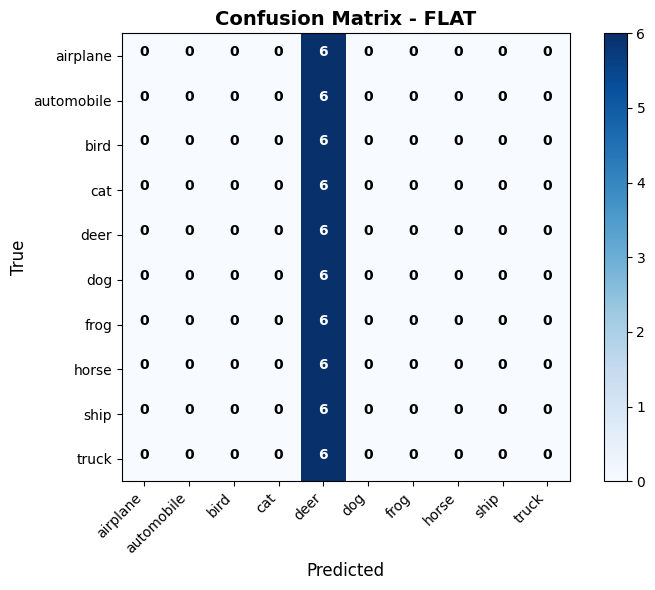

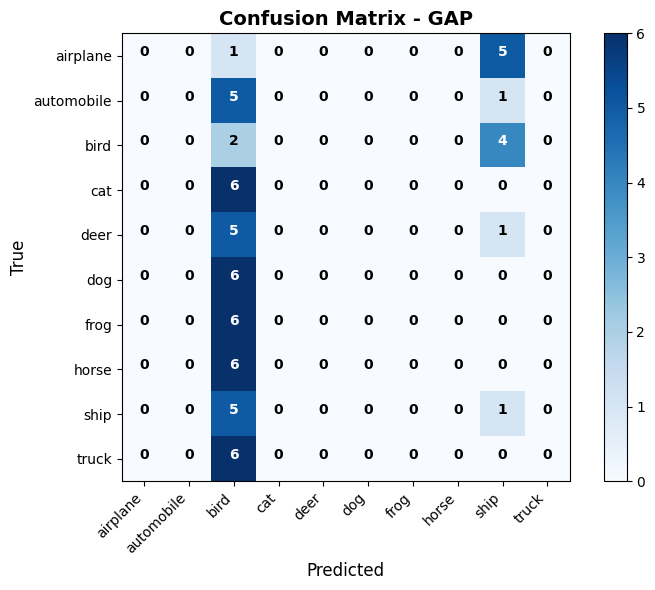


=== PHÂN TÍCH CHI TIẾT FLAT ===
Ma trận confusion matrix 10x10:
[[0 0 0 0 6 0 0 0 0 0]
 [0 0 0 0 6 0 0 0 0 0]
 [0 0 0 0 6 0 0 0 0 0]
 [0 0 0 0 6 0 0 0 0 0]
 [0 0 0 0 6 0 0 0 0 0]
 [0 0 0 0 6 0 0 0 0 0]
 [0 0 0 0 6 0 0 0 0 0]
 [0 0 0 0 6 0 0 0 0 0]
 [0 0 0 0 6 0 0 0 0 0]
 [0 0 0 0 6 0 0 0 0 0]]

Lớp 'airplane' (True):
  - Tổng số mẫu: 6
  - Dự đoán đúng: 0 (0.0%)
  - Lỗi: 6 mẫu nhầm thành 'deer'

Lớp 'automobile' (True):
  - Tổng số mẫu: 6
  - Dự đoán đúng: 0 (0.0%)
  - Lỗi: 6 mẫu nhầm thành 'deer'

Lớp 'bird' (True):
  - Tổng số mẫu: 6
  - Dự đoán đúng: 0 (0.0%)
  - Lỗi: 6 mẫu nhầm thành 'deer'

Lớp 'cat' (True):
  - Tổng số mẫu: 6
  - Dự đoán đúng: 0 (0.0%)
  - Lỗi: 6 mẫu nhầm thành 'deer'

Lớp 'deer' (True):
  - Tổng số mẫu: 6
  - Dự đoán đúng: 6 (100.0%)

Lớp 'dog' (True):
  - Tổng số mẫu: 6
  - Dự đoán đúng: 0 (0.0%)
  - Lỗi: 6 mẫu nhầm thành 'deer'

Lớp 'frog' (True):
  - Tổng số mẫu: 6
  - Dự đoán đúng: 0 (0.0%)
  - Lỗi: 6 mẫu nhầm thành 'deer'

Lớp 'horse' (True):
  - Tổng số m

In [9]:
# Vẽ CM cho từng mô hình với số hiển thị
def plot_cm(cm, title):
    plt.figure(figsize=(8, 6))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title(title, fontsize=14, fontweight='bold')
    plt.colorbar()

    # Hiển thị số trong từng ô
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, format(cm[i, j], 'd'),
                    horizontalalignment="center",
                    color="white" if cm[i, j] > thresh else "black",
                    fontsize=10, fontweight='bold')

    ticks = np.arange(len(class_names))
    plt.xticks(ticks, class_names, rotation=45, ha='right')
    plt.yticks(ticks, class_names)
    plt.xlabel('Predicted', fontsize=12)
    plt.ylabel('True', fontsize=12)
    plt.tight_layout()
    plt.show()

# Gọi hàm vẽ
plot_cm(res_flat["cm"], "Confusion Matrix - FLAT")
plot_cm(res_gap["cm"], "Confusion Matrix - GAP")
# Phân tích chi tiết confusion matrix
def analyze_confusion_matrix(cm, model_name, class_names):
    print(f"\n=== PHÂN TÍCH CHI TIẾT {model_name} ===")
    print(f"Ma trận confusion matrix {cm.shape[0]}x{cm.shape[1]}:")
    print(cm)
    print()

    # Phân tích từng hàng (true labels)
    for i, true_class in enumerate(class_names):
        row = cm[i, :]
        total_true = row.sum()
        correct = cm[i, i]

        print(f"Lớp '{true_class}' (True):")
        print(f"  - Tổng số mẫu: {total_true}")
        print(f"  - Dự đoán đúng: {correct} ({correct/total_true*100:.1f}%)")

        # Liệt kê các lỗi
        errors = []
        for j, predicted_class in enumerate(class_names):
            if i != j and cm[i, j] > 0:
                errors.append(f"{cm[i, j]} mẫu nhầm thành '{predicted_class}'")

        if errors:
            print(f"  - Lỗi: {', '.join(errors)}")
        print()

# Gọi hàm phân tích
analyze_confusion_matrix(res_flat["cm"], "FLAT", class_names)
analyze_confusion_matrix(res_gap["cm"], "GAP", class_names)



In [10]:
def compare_confusion_matrices(cm1, cm2, name1="FLAT", name2="GAP"):
    print(f"\n=== SO SÁNH {name1} vs {name2} ===")

    # Tính accuracy từng lớp
    acc1 = np.diag(cm1) / cm1.sum(axis=1)
    acc2 = np.diag(cm2) / cm2.sum(axis=1)

    print("Accuracy từng lớp:")
    print(f"{'Class':<12} {name1:<8} {name2:<8} {'Chênh lệch'}")
    print("-" * 40)

    for i, class_name in enumerate(class_names):
        diff = acc2[i] - acc1[i]
        symbol = "+" if diff > 0 else ""
        print(f"{class_name:<12} {acc1[i]:.3f}    {acc2[i]:.3f}    {symbol}{diff:.3f}")

    print()
    print(f"Overall accuracy: {name1}: {np.trace(cm1)/cm1.sum():.3f}")
    print(f"Overall accuracy: {name2}: {np.trace(cm2)/cm2.sum():.3f}")

# Gọi hàm so sánh
compare_confusion_matrices(res_flat["cm"], res_gap["cm"])



=== SO SÁNH FLAT vs GAP ===
Accuracy từng lớp:
Class        FLAT     GAP      Chênh lệch
----------------------------------------
airplane     0.000    0.000    0.000
automobile   0.000    0.000    0.000
bird         0.000    0.333    +0.333
cat          0.000    0.000    0.000
deer         1.000    0.000    -1.000
dog          0.000    0.000    0.000
frog         0.000    0.000    0.000
horse        0.000    0.000    0.000
ship         0.000    0.167    +0.167
truck        0.000    0.000    0.000

Overall accuracy: FLAT: 0.100
Overall accuracy: GAP: 0.050


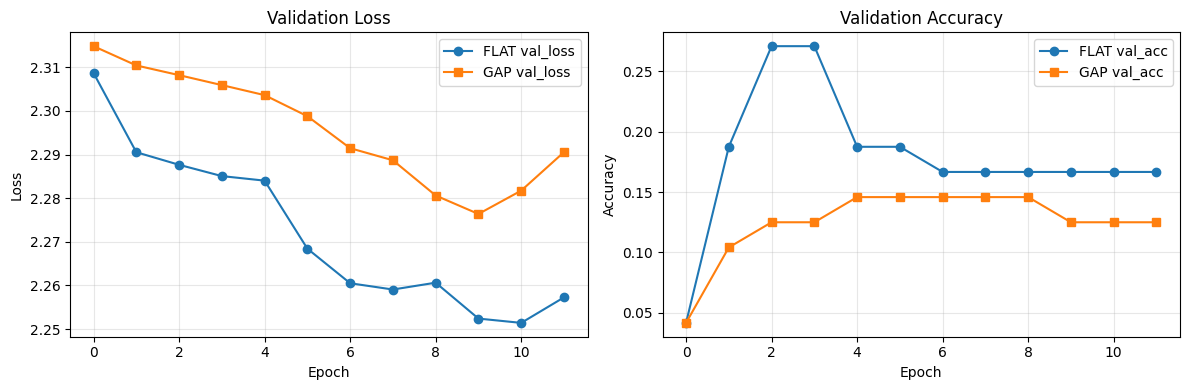

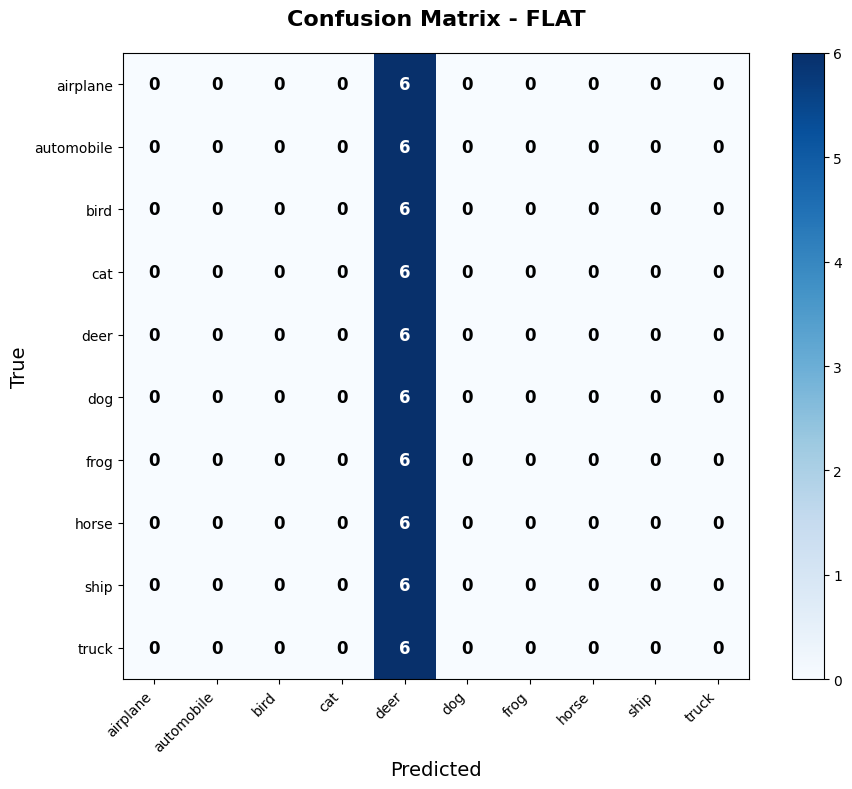

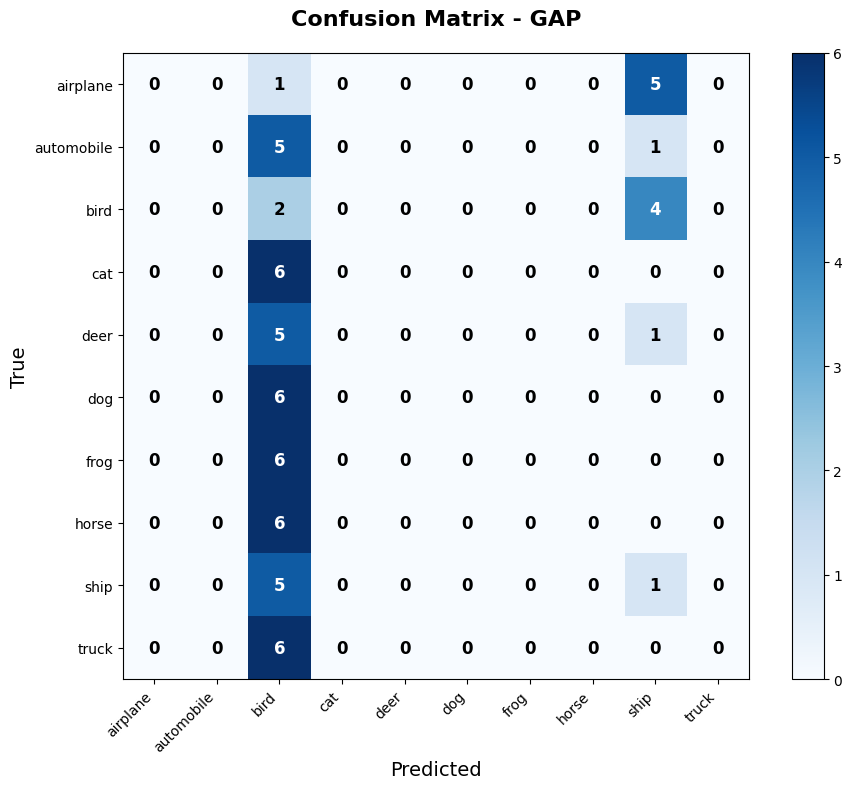


=== PHÂN TÍCH CHI TIẾT FLAT ===
Ma trận confusion matrix 10x10:
[[0 0 0 0 6 0 0 0 0 0]
 [0 0 0 0 6 0 0 0 0 0]
 [0 0 0 0 6 0 0 0 0 0]
 [0 0 0 0 6 0 0 0 0 0]
 [0 0 0 0 6 0 0 0 0 0]
 [0 0 0 0 6 0 0 0 0 0]
 [0 0 0 0 6 0 0 0 0 0]
 [0 0 0 0 6 0 0 0 0 0]
 [0 0 0 0 6 0 0 0 0 0]
 [0 0 0 0 6 0 0 0 0 0]]

Lớp 'airplane' (True):
  - Tổng số mẫu: 6
  - Dự đoán đúng: 0 (0.0%)
  - Lỗi: 6 mẫu nhầm thành 'deer'

Lớp 'automobile' (True):
  - Tổng số mẫu: 6
  - Dự đoán đúng: 0 (0.0%)
  - Lỗi: 6 mẫu nhầm thành 'deer'

Lớp 'bird' (True):
  - Tổng số mẫu: 6
  - Dự đoán đúng: 0 (0.0%)
  - Lỗi: 6 mẫu nhầm thành 'deer'

Lớp 'cat' (True):
  - Tổng số mẫu: 6
  - Dự đoán đúng: 0 (0.0%)
  - Lỗi: 6 mẫu nhầm thành 'deer'

Lớp 'deer' (True):
  - Tổng số mẫu: 6
  - Dự đoán đúng: 6 (100.0%)

Lớp 'dog' (True):
  - Tổng số mẫu: 6
  - Dự đoán đúng: 0 (0.0%)
  - Lỗi: 6 mẫu nhầm thành 'deer'

Lớp 'frog' (True):
  - Tổng số mẫu: 6
  - Dự đoán đúng: 0 (0.0%)
  - Lỗi: 6 mẫu nhầm thành 'deer'

Lớp 'horse' (True):
  - Tổng số m

In [11]:
def plot_hist_compare(h1, h2, label1="flat", label2="gap"):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    # Validation loss
    ax1.plot(h1.history['val_loss'], label=f'{label1} val_loss', marker='o')
    ax1.plot(h2.history['val_loss'], label=f'{label2} val_loss', marker='s')
    ax1.set_title("Validation Loss")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Validation accuracy
    ax2.plot(h1.history['val_accuracy'], label=f'{label1} val_acc', marker='o')
    ax2.plot(h2.history['val_accuracy'], label=f'{label2} val_acc', marker='s')
    ax2.set_title("Validation Accuracy")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

def plot_cm_with_numbers(cm, title):
    plt.figure(figsize=(10, 8))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title(title, fontsize=16, fontweight='bold', pad=20)
    plt.colorbar()

    # Hiển thị số trong từng ô
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, format(cm[i, j], 'd'),
                    horizontalalignment="center",
                    verticalalignment="center",
                    color="white" if cm[i, j] > thresh else "black",
                    fontsize=12, fontweight='bold')

    ticks = np.arange(len(class_names))
    plt.xticks(ticks, class_names, rotation=45, ha='right')
    plt.yticks(ticks, class_names)
    plt.xlabel('Predicted', fontsize=14)
    plt.ylabel('True', fontsize=14)
    plt.tight_layout()
    plt.show()

# Chạy phân tích
plot_hist_compare(hist_flat, hist_gap, "FLAT", "GAP")
plot_cm_with_numbers(res_flat["cm"], "Confusion Matrix - FLAT")
plot_cm_with_numbers(res_gap["cm"], "Confusion Matrix - GAP")

# Phân tích chi tiết
analyze_confusion_matrix(res_flat["cm"], "FLAT", class_names)
analyze_confusion_matrix(res_gap["cm"], "GAP", class_names)
compare_confusion_matrices(res_flat["cm"], res_gap["cm"])
